# Neural Networks

<h4> 1. Importimi i librarive te nevojshme <h4>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

<h4> 2. Percaktimi i folderave dhe parametrave <h4>

In [ ]:
BASE_DIR = os.getcwd()
METADATA_PATH = os.path.join(BASE_DIR, "HAM10000_metadata_filtered.csv")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 15

print("Base directory:", BASE_DIR)

Base directory: c:\Users\vesav\Desktop\DermaScan\ham_dataset


<h4> 3. Ngarkimi i metadata <h4>

In [ ]:
_df = pd.read_csv(METADATA_PATH)
print(_df.head())
print(_df.info())

     lesion_id      image_id   dx dx_type   age     sex     localization
0  HAM_0000871  ISIC_0025964  mel   histo  40.0  female            chest
1  HAM_0000871  ISIC_0030623  mel   histo  40.0  female            chest
2  HAM_0000040  ISIC_0027190  mel   histo  80.0    male  upper extremity
3  HAM_0005678  ISIC_0031023  mel   histo  60.0    male            chest
4  HAM_0005678  ISIC_0028086  mel   histo  60.0    male            chest
<class 'pandas.DataFrame'>
RangeIndex: 2226 entries, 0 to 2225
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     2226 non-null   str    
 1   image_id      2226 non-null   str    
 2   dx            2226 non-null   str    
 3   dx_type       2226 non-null   str    
 4   age           2218 non-null   float64
 5   sex           2226 non-null   str    
 6   localization  2226 non-null   str    
dtypes: float64(1), str(6)
memory usage: 121.9 KB
None


<h4> 4. Mbajtja vetem e klasave mel dhe nv <h4>

In [ ]:
df = _df[_df["dx"].isin(["mel", "nv"])].copy()

print("Numri i imazheve:", len(df))
print(df["dx"].value_counts())

Numri i imazheve: 2226
dx
mel    1113
nv     1113
Name: count, dtype: int64


<h4> 5. Krijimi i path-it per secilin imazh <h4>

In [ ]:
def get_image_path(row):
    return os.path.join(BASE_DIR, row["dx"], row["image_id"] + ".jpg")

df["image_path"] = df.apply(get_image_path, axis=1)

df["exists"] = df["image_path"].apply(os.path.exists)
print("Imazhe qe mungojne:", len(df[df["exists"] == False]))

df = df[df["exists"] == True].copy()
df = df.drop(columns=["exists"])
df.head()

Imazhe qe mungojne: 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000871,ISIC_0025964,mel,histo,40.0,female,chest,c:\Users\vesav\Desktop\DermaScan\ham_dataset\m...
1,HAM_0000871,ISIC_0030623,mel,histo,40.0,female,chest,c:\Users\vesav\Desktop\DermaScan\ham_dataset\m...
2,HAM_0000040,ISIC_0027190,mel,histo,80.0,male,upper extremity,c:\Users\vesav\Desktop\DermaScan\ham_dataset\m...
3,HAM_0005678,ISIC_0031023,mel,histo,60.0,male,chest,c:\Users\vesav\Desktop\DermaScan\ham_dataset\m...
4,HAM_0005678,ISIC_0028086,mel,histo,60.0,male,chest,c:\Users\vesav\Desktop\DermaScan\ham_dataset\m...


<h4>6. Ndarja e te dhenave ne train dhe test<h4>

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["dx"]
)

print("Train:")
print(train_df["dx"].value_counts())

print("\nTest:")
print(test_df["dx"].value_counts())

Train:
dx
nv     890
mel    890
Name: count, dtype: int64

Test:
dx
nv     223
mel    223
Name: count, dtype: int64


<h4>7. Gjenerimi dhe normalizimi i imazheve<h4>

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

<h4>8. Krijimi i train, validation dhe test generator<h4>

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["nv", "mel"],
    subset="training",
    seed=42
)

validation_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["nv", "mel"],
    subset="validation",
    seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["nv", "mel"],
    shuffle=False
)

print(train_generator.class_indices)

Found 1424 validated image filenames belonging to 2 classes.
Found 356 validated image filenames belonging to 2 classes.
Found 446 validated image filenames belonging to 2 classes.
{'nv': 0, 'mel': 1}


<h4> 9. Shfaqja e disa imazheve nga dataseti <h4>

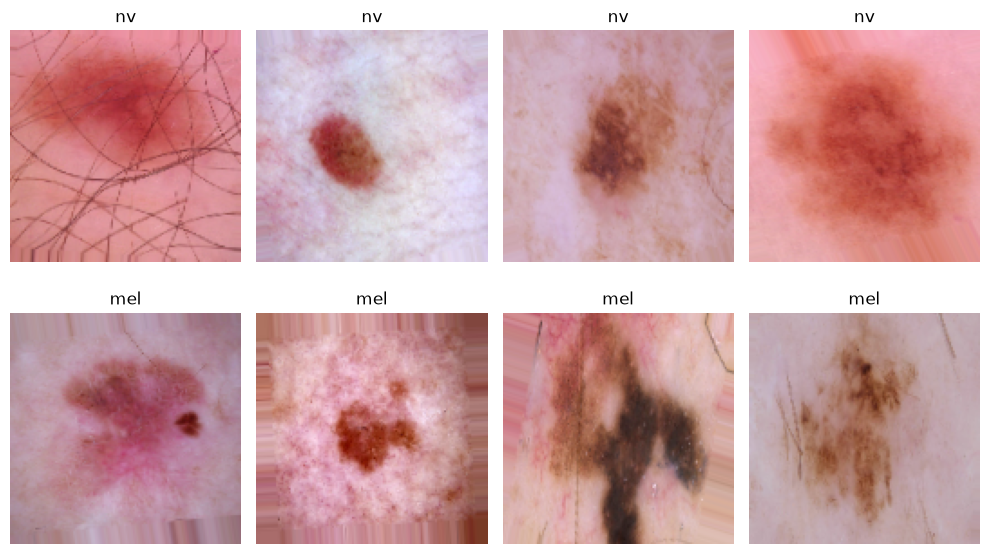

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title("mel" if labels[i] == 1 else "nv")
    plt.axis("off")

plt.tight_layout()
plt.show()

<h4> 10. Krijimi i modelit neural CNN <h4>

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))

model.summary()

c:\Users\vesav\Desktop\DermaScan\.lab2\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

<h4> 11. Kompilimi i modelit <h4>

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# binary_crossentropy perdoret per klasifikim binar
# sigmoid jep probabilitet nga 0 deri ne 1
# 0 = nv, 1 = mel

<h4> 12. Trajnimi i modelit <h4>

In [ ]:

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 644ms/step - accuracy: 0.5625 - loss: 0.6832 - val_accuracy: 0.6124 - val_loss: 0.5795
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 580ms/step - accuracy: 0.7037 - loss: 0.5755 - val_accuracy: 0.6545 - val_loss: 0.5835
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 584ms/step - accuracy: 0.6706 - loss: 0.5735 - val_accuracy: 0.7388 - val_loss: 0.5335
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 579ms/step - accuracy: 0.7367 - loss: 0.5210 - val_accuracy: 0.7135 - val_loss: 0.5389
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 576ms/step - accuracy: 0.7514 - loss: 0.5031 - val_accuracy: 0.7416 - val_loss: 0.5157
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 579ms/step - accuracy: 0.7346 - loss: 0.5199 - val_accuracy: 0.7500 - val_loss: 0.5208
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 579ms/step - accuracy: 0.7402 - loss: 0.4976 - val_accuracy: 0.7472 - val_loss: 0.4708
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 26s 579ms/step - accuracy: 0.7353 - loss: 0.5097 - val_accu

<h4> 13. Vizualizimi i saktesise dhe humbjes gjate trajnimit <h4>

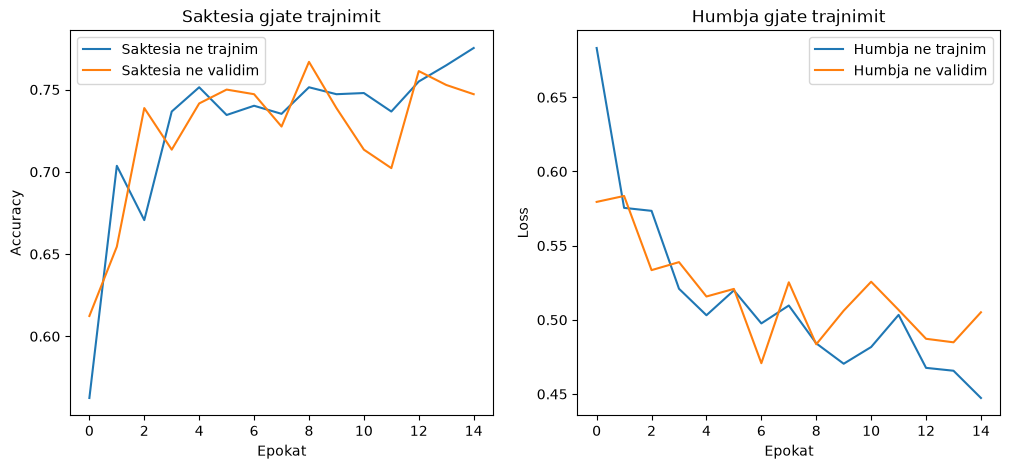

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Saktesia ne trajnim")
plt.plot(history.history["val_accuracy"], label="Saktesia ne validim")
plt.xlabel("Epokat")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Saktesia gjate trajnimit")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Humbja ne trajnim")
plt.plot(history.history["val_loss"], label="Humbja ne validim")
plt.xlabel("Epokat")
plt.ylabel("Loss")
plt.legend()
plt.title("Humbja gjate trajnimit")

plt.show()

<h4>14. Testimi i modelit <h4>

In [ ]:
loss, accuracy = model.evaluate(test_generator)

print(f"Loss ne test: {loss:.4f}")
print(f"Accuracy ne test: {accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 294ms/step - accuracy: 0.7197 - loss: 0.5175
Loss ne test: 0.5175
Accuracy ne test: 0.7197


<h4> 15. Raporti i klasifikimit dhe matrica e konfuzionit <h4>

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 311ms/step
              precision    recall  f1-score   support

          nv       0.85      0.54      0.66       223
         mel       0.66      0.90      0.76       223

    accuracy                           0.72       446
   macro avg       0.75      0.72      0.71       446
weighted avg       0.75      0.72      0.71       446



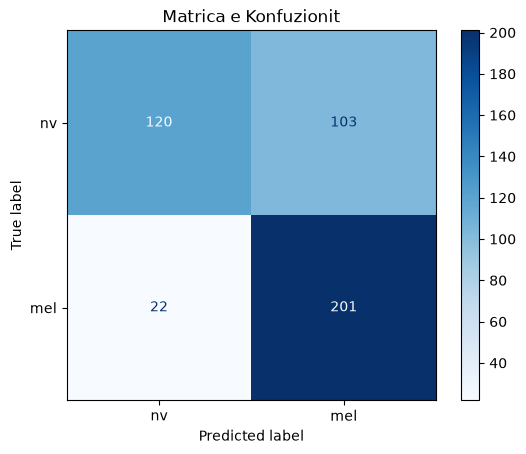

In [ ]:
pred_prob = model.predict(test_generator)
y_pred = (pred_prob > 0.5).astype("int32").flatten()
y_true = test_generator.classes

print(classification_report(y_true, y_pred, target_names=["nv", "mel"]))

cm = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["nv", "mel"])
display.plot(cmap="Blues")
plt.title("Matrica e Konfuzionit")
plt.show()

<h4>16. Ruajtja e modelit <h4>

In [ ]:
model.save("neural_network_ham10000.keras")
print("Modeli u ruajt me sukses.")

Modeli u ruajt me sukses.
